# **Demand Forecasting**
Dataset: `https://archive.ics.uci.edu/dataset/502/online+retail+ii`
## Path Config
After downloading the dataset, upload the file to Google Colab and update the dataset path below if necessary.

In [5]:
from pathlib import Path

DATA_PATH = Path("/content/online_retail_II.xlsx")
SHEET_1 = "Year 2009-2010"
SHEET_2 = "Year 2010-2011"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"File not found: {DATA_PATH}\n"
        "Change DATA_PATH."
    )

print(DATA_PATH)

/content/online_retail_II.xlsx


## Library

In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print("pandas:", pd.__version__)
print("numpy :", np.__version__)

pandas: 2.2.3
numpy : 2.1.3


In [7]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
    print("Prophet available.")
except ImportError:
    PROPHET_AVAILABLE = False
    print("Prophet not available. Install: pip install prophet")

Prophet available.


## Preview Dataset

In [8]:
df_2009_2010 = pd.read_excel(
    DATA_PATH, sheet_name=SHEET_1, engine="openpyxl"
)

df_2010_2011 = pd.read_excel(
    DATA_PATH, sheet_name=SHEET_2, engine="openpyxl"
)

print("Sheet 2009-2010 dimension shape:", df_2009_2010.shape)
print("Sheet 2010-2011 dimension shape:", df_2010_2011.shape)

Sheet 2009-2010 dimension shape: (525461, 8)
Sheet 2010-2011 dimension shape: (541910, 8)


Column Inspect

In [9]:
print("Sheet 2009-2010 header:", df_2009_2010.columns.tolist())
print("Sheet 2010-2011 header:",df_2010_2011.columns.tolist())

Sheet 2009-2010 header: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
Sheet 2010-2011 header: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


Concatenate Data

In [10]:
df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.replace(" ", "", regex=False)
)

print("Combined shape:", df.shape)
display(df.head())

Combined shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Check Missing Value

In [11]:
df.info()

print("\nDuplicates:", df.duplicated().sum())

missing = df.isna().sum().sort_values(ascending=False)
display(pd.DataFrame({
    "missing_count": missing,
    "missing_pct": (missing / len(df) * 100).round(2)
}))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   CustomerID   824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB

Duplicates: 34335


,missing_count,missing_pct
CustomerID,243007,22.77
Description,4382,0.41
StockCode,0,0.00
Invoice,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Country,0,0.00


## Datetime dan numeric conversion

In [12]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

df["Quantity"] = pd.to_numeric(
    df["Quantity"],
    errors="coerce"
)

df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)

print("InvoiceDate NaT:", df["InvoiceDate"].isna().sum())
print("Date:", df["InvoiceDate"].min(), "->", df["InvoiceDate"].max())

InvoiceDate NaT: 0
Date: 2009-12-01 07:45:00 -> 2011-12-09 12:50:00


## Checking Cancellation and Revenue

Revenue formula:
$$
Revenue=Quantity × Price
$$

In [13]:
df["Invoice"] = df["Invoice"].astype("string").str.strip()

# Cancelattion is marked with "C" in the Invoice
df["is_cancellation"] = (
    df["Invoice"].str.upper().str.startswith("C", na=False)
)

df["Revenue"] = df["Quantity"] * df["Price"]

# Cancellation value is maintained as a negative value
df["NetRevenue"] = df["Revenue"]

print("Cancellation rows:", df["is_cancellation"].sum())

display(df[[
    "Invoice", "Quantity", "Price",
    "is_cancellation", "NetRevenue"
]].head(10))

Cancellation rows: 19494


,Invoice,Quantity,Price,is_cancellation,NetRevenue
0,489434,12,6.95,False,83.4
1,489434,12,6.75,False,81.0
2,489434,12,6.75,False,81.0
3,489434,48,2.10,False,100.8
4,489434,24,1.25,False,30.0
5,489434,24,1.65,False,39.6
6,489434,24,1.25,False,30.0
7,489434,10,5.95,False,59.5
8,489435,12,2.55,False,30.6
9,489435,12,3.75,False,45.0


## Transaction Statistics

In [14]:
display(df[["Quantity", "Price", "NetRevenue"]].describe())

print("Unique invoices :", df["Invoice"].nunique())
print("Unique products :", df["StockCode"].nunique())
print("Unique customers:", df["CustomerID"].nunique())
print("Unique countries:", df["Country"].nunique())

,Quantity,Price,NetRevenue
count,1.067371e+06,1.067371e+06,1.067371e+06
mean,9.938898e+00,4.649388e+00,1.806987e+01
std,1.727058e+02,1.235531e+02,2.924202e+02
min,-8.099500e+04,-5.359436e+04,-1.684696e+05
25%,1.000000e+00,1.250000e+00,3.750000e+00
50%,3.000000e+00,2.100000e+00,9.900000e+00
75%,1.000000e+01,4.150000e+00,1.770000e+01
max,8.099500e+04,3.897000e+04,1.684696e+05


Unique invoices : 53628
Unique products : 5305
Unique customers: 5942
Unique countries: 43


## Daily Aggregation

In [15]:
daily = (
    df.dropna(subset=["InvoiceDate"])
      .set_index("InvoiceDate")["NetRevenue"]
      .resample("D")
      .sum()
      .rename("sales")
      .to_frame()
)

# Checking missing periods
full_index = pd.date_range(
    daily.index.min(),
    daily.index.max(),
    freq="D"
)

daily_full = daily.reindex(full_index)
daily_full.index.name = "date"

print("Calendar days:", len(daily_full))
print("Missing transaction days:", daily_full["sales"].isna().sum())

Calendar days: 739
Missing transaction days: 0


In [16]:
daily_raw = daily_full.copy()

# Hari tanpa transaksi diperlakukan sebagai 0 untuk forecasting.
daily_forecast = daily_full.fillna(0)

display(daily_forecast.head())

,sales
date,
2009-12-01,53173.03
2009-12-02,62763.59
2009-12-03,68093.05
2009-12-04,40346.40
2009-12-05,9803.05


## Weekly Aggregation

In [17]:
weekly = (
    daily_forecast["sales"]
    .resample("W-MON", label="left", closed="left")
    .sum()
    .rename("sales")
    .to_frame()
)

display(weekly.head())

,sales
date,
2009-11-30,258496.32
2009-12-07,232310.10
2009-12-14,256240.20
2009-12-21,52800.49
2009-12-28,0.00


## Monthly Aggregation

In [18]:
monthly = (
    daily_forecast["sales"]
    .resample("MS")
    .sum()
    .rename("sales")
    .to_frame()
)

display(monthly)

,sales
date,
2009-12-01,799847.110
2010-01-01,624032.892
2010-02-01,533091.426
2010-03-01,765848.761
2010-04-01,590580.432
2010-05-01,615322.830
2010-06-01,679786.610
2010-07-01,575236.360
2010-08-01,656776.340


## Raw Daily Time Series

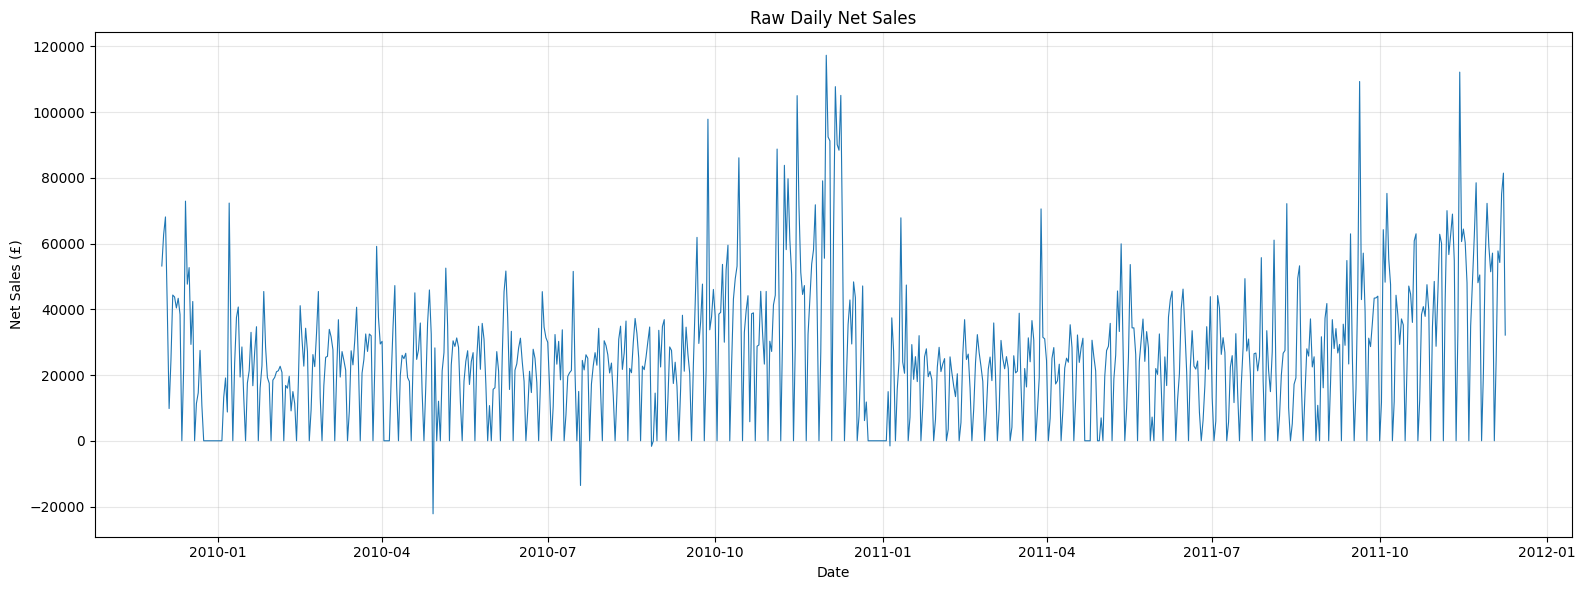

In [19]:
plt.figure(figsize=(16, 6))
plt.plot(daily_raw.index, daily_raw["sales"], linewidth=0.8)
plt.title("Raw Daily Net Sales")
plt.xlabel("Date")
plt.ylabel("Net Sales (£)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Weekly and monthly time series

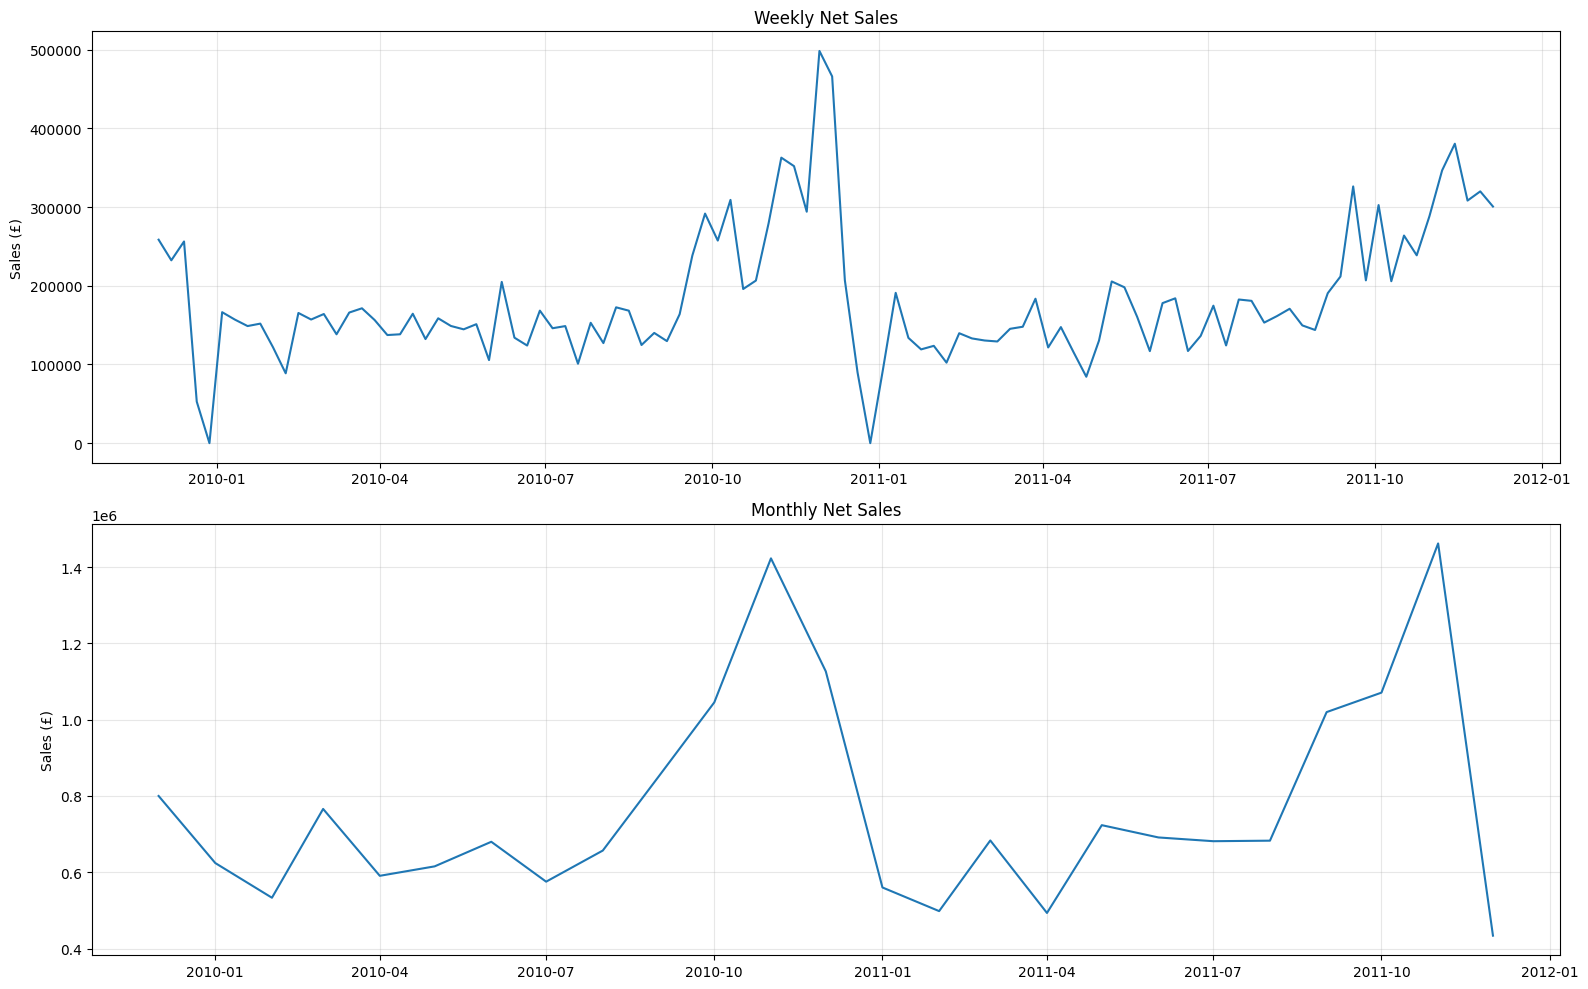

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(weekly.index, weekly["sales"])
axes[0].set_title("Weekly Net Sales")
axes[0].set_ylabel("Sales (£)")
axes[0].grid(alpha=0.3)

axes[1].plot(monthly.index, monthly["sales"])
axes[1].set_title("Monthly Net Sales")
axes[1].set_ylabel("Sales (£)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Trend Analysis


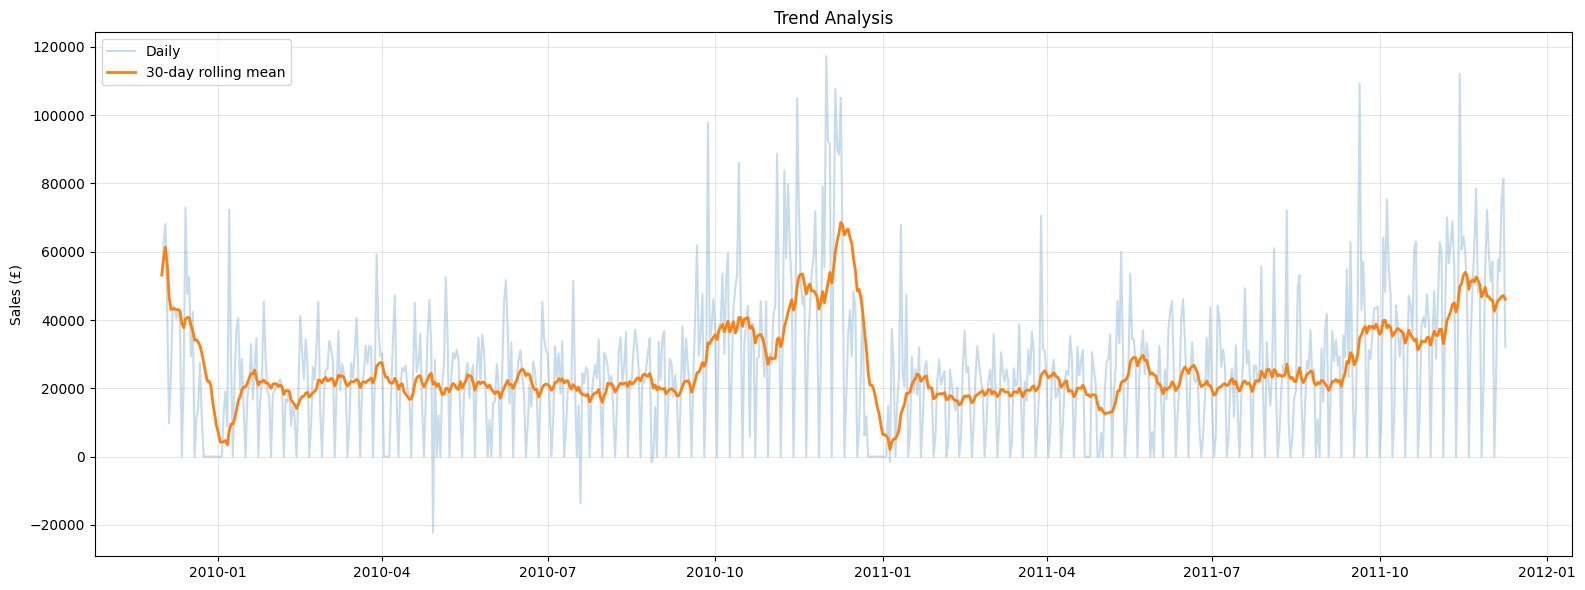

In [21]:
rolling_30 = daily_forecast["sales"].rolling(
    15, min_periods=1
).mean()

plt.figure(figsize=(16, 6))
plt.plot(
    daily_forecast.index,
    daily_forecast["sales"],
    alpha=0.25,
    label="Daily"
)
plt.plot(
    rolling_30.index,
    rolling_30,
    linewidth=2,
    label="30-day rolling mean"
)
plt.title("Trend Analysis")
plt.ylabel("Sales (£)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Day-of-week seasonality

In [22]:
cal = daily_forecast.copy()
cal["day_of_week"] = cal.index.day_name()
cal["month"] = cal.index.month
cal["year"] = cal.index.year

dow_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

dow_summary = (
    cal.groupby("day_of_week")["sales"]
       .agg(["mean", "median", "sum", "count"])
       .reindex(dow_order)
)

display(dow_summary)

,mean,median,sum,count
day_of_week,,,,
Monday,31763.962914,27173.320,3335216.106,105
Tuesday,35612.016717,31132.740,3774873.772,106
Wednesday,31983.377481,27756.135,3390238.013,106
Thursday,37688.981245,33670.160,3995032.012,106
Friday,27883.028708,25704.145,2955601.043,106
Saturday,93.362381,0.000,9803.050,105
Sunday,17395.110210,16823.770,1826486.572,105


## Day-of-week plot

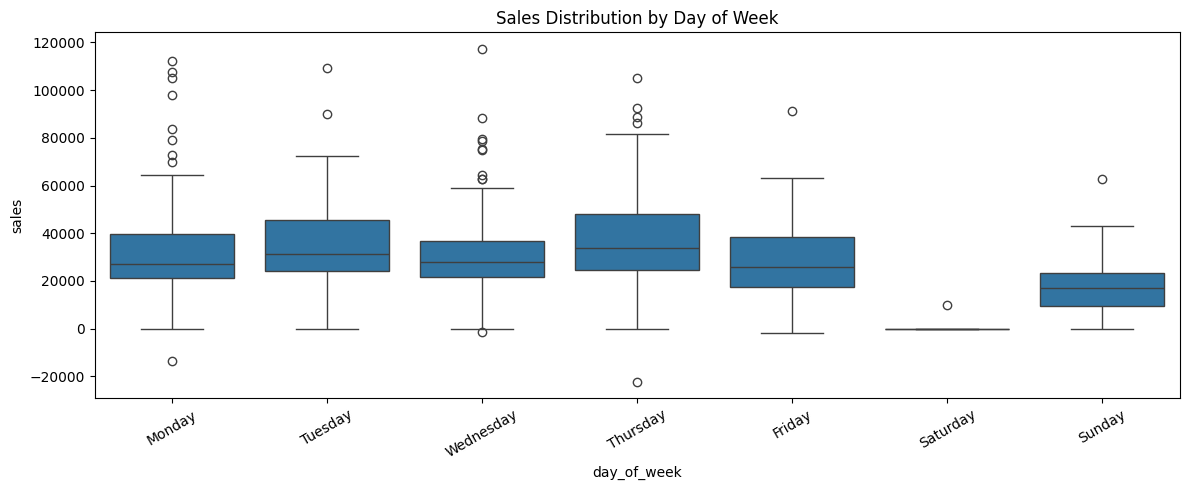

In [23]:
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=cal,
    x="day_of_week",
    y="sales",
    order=dow_order
)
plt.title("Sales Distribution by Day of Week")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Monthly seasonality

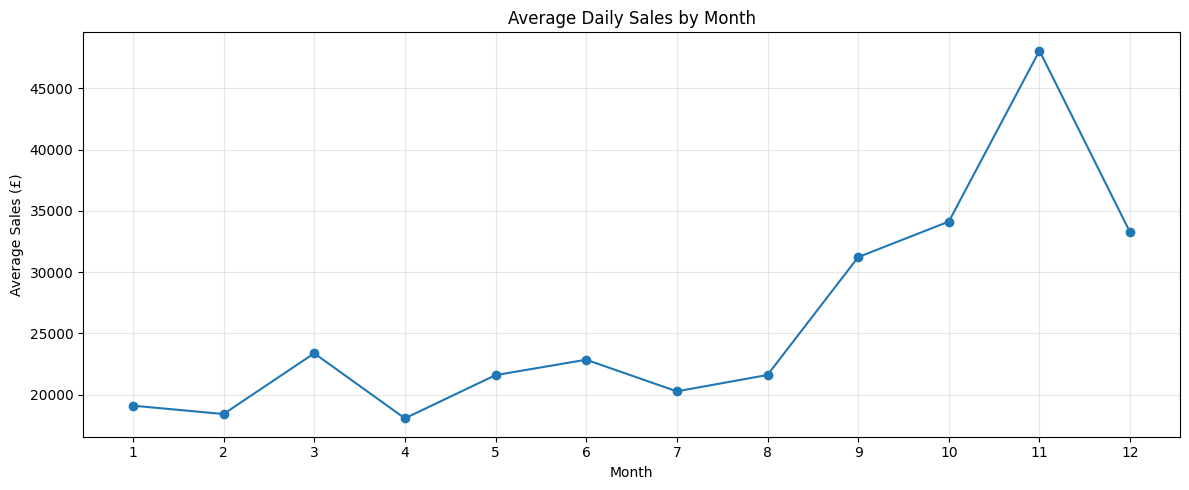

In [24]:
month_summary = cal.groupby("month")["sales"].mean()

plt.figure(figsize=(12, 5))
plt.plot(
    month_summary.index,
    month_summary.values,
    marker="o"
)
plt.xticks(range(1, 13))
plt.title("Average Daily Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales (£)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Outliers with IQR

In [25]:
# CELL 21 — Outliers dengan IQR

q1 = daily_forecast["sales"].quantile(0.25)
q3 = daily_forecast["sales"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = daily_forecast[
    (daily_forecast["sales"] < lower) |
    (daily_forecast["sales"] > upper)
]

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower:", lower)
print("Upper:", upper)
print("Outliers:", len(outliers))

display(outliers.sort_values("sales", ascending=False).head(20))

Q1: 12427.28
Q3: 35710.07
IQR: 23282.79
Lower: -22496.905
Upper: 70634.255
Outliers: 26


,sales
date,
2010-12-01,117271.120
2011-11-14,112141.110
2011-09-20,109286.210
2010-12-06,107720.360
2010-12-09,105064.260
2010-11-15,104983.550
2010-09-27,97814.700
2010-12-02,92414.560
2010-12-03,91240.920


Sudden Change

In [26]:
pct_change = (
    daily_forecast["sales"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
)

sudden_changes = (
    pct_change.abs()
    .sort_values(ascending=False)
    .head(20)
    .to_frame("absolute_pct_change")
)

display(sudden_changes)

,absolute_pct_change
date,
2011-01-06,24.874361
2010-01-07,7.267372
2011-07-04,6.387271
2011-02-07,6.383621
2010-10-21,5.662785
2011-03-14,5.251079
2011-10-03,4.524527
2011-02-14,3.737152
2010-09-27,3.578360


Missing Periods

In [27]:
missing_dates = daily_raw[
    daily_raw["sales"].isna()
].index

print("Missing calendar days:", len(missing_dates))

if len(missing_dates):
    print(missing_dates[:20])

Missing calendar days: 0


## Metrics
Define metrics for evaluating model, such as MAPE (Mean Absolute Percentage Error), MAE (Mean Absolute Error), and  

In [28]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return (
        np.mean(
            np.abs(
                (y_true[mask] - y_pred[mask]) /
                y_true[mask]
            )
        ) * 100
    )


def evaluate_forecast(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE (%)": mape(y_true, y_pred)
    }

Time-based train/test split

In [29]:
# Weekly series is used for modeling.
series = weekly["sales"].copy()

TEST_RATIO = 0.20
test_size = max(8, int(len(series) * TEST_RATIO))

train = series.iloc[:-test_size]
test = series.iloc[-test_size:]

print("Train:", train.index.min(), "->", train.index.max(), len(train))
print("Test :", test.index.min(), "->", test.index.max(), len(test))

Train: 2009-11-30 00:00:00 -> 2011-07-11 00:00:00 85
Test : 2011-07-18 00:00:00 -> 2011-12-05 00:00:00 21


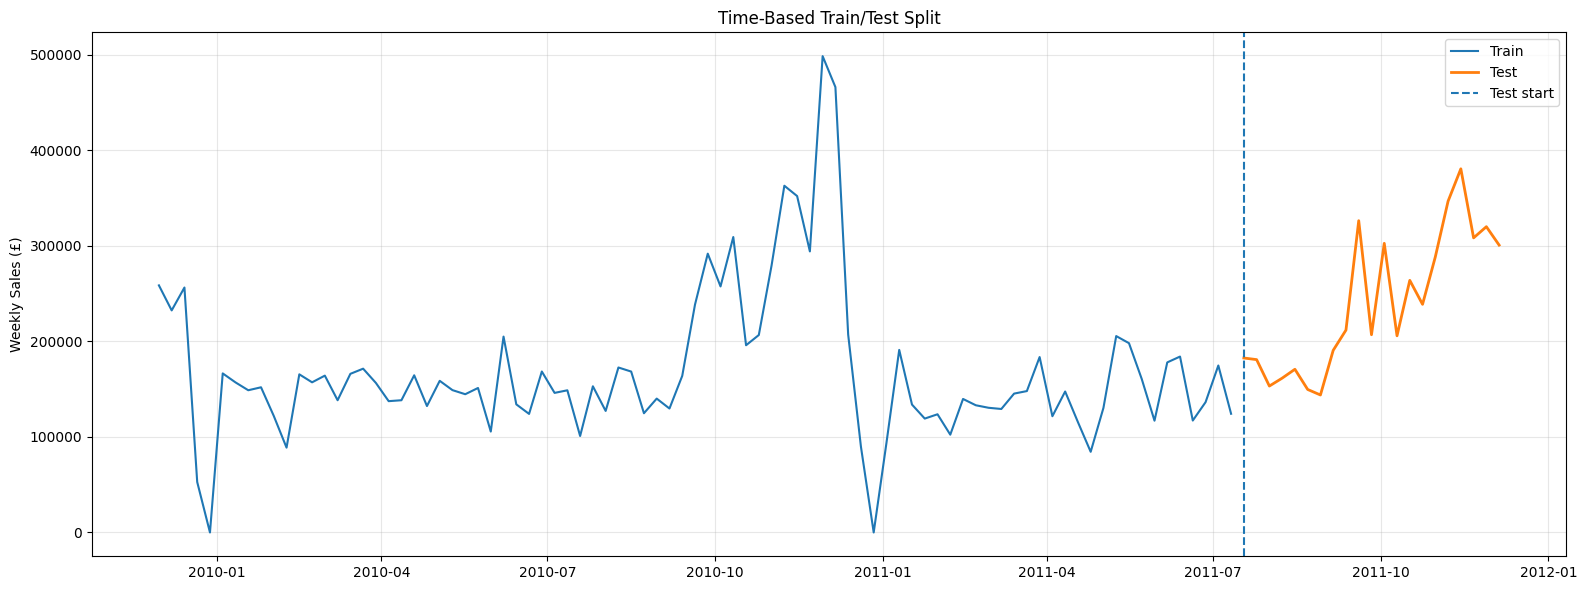

In [30]:
# CELL 26 — Train/test plot

plt.figure(figsize=(16, 6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", linewidth=2)
plt.axvline(test.index[0], linestyle="--", label="Test start")
plt.title("Time-Based Train/Test Split")
plt.ylabel("Weekly Sales (£)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Baseline

In [31]:
# CELL 27 — Baselines

baseline_results = []

# Previous period
naive_pred = pd.Series(
    train.iloc[-1],
    index=test.index
)

baseline_results.append(
    evaluate_forecast(
        test,
        naive_pred,
        "Previous-period Naive"
    )
)

# Moving average
WINDOW = 4

moving_average_pred = pd.Series(
    train.iloc[-WINDOW:].mean(),
    index=test.index
)

baseline_results.append(
    evaluate_forecast(
        test,
        moving_average_pred,
        f"{WINDOW}-week Moving Average"
    )
)

# Seasonal naive: 52-week lag
SEASONAL_LAG = 52

if len(train) >= SEASONAL_LAG:
    seasonal_values = train.iloc[-SEASONAL_LAG:].values

    seasonal_naive_pred = pd.Series(
        np.resize(seasonal_values, len(test)),
        index=test.index
    )

    baseline_results.append(
        evaluate_forecast(
            test,
            seasonal_naive_pred,
            "Seasonal Naive (52 weeks)"
        )
    )

baseline_df = pd.DataFrame(baseline_results)
display(baseline_df)

,Model,MAE,RMSE,MAPE (%)
0,Previous-period Naive,115448.44300,135953.517416,43.281348
1,4-week Moving Average,101562.49050,124378.275367,36.938143
2,Seasonal Naive (52 weeks),53282.01381,71923.745822,22.005612


## ARIMA (Autoregressive Integrated Moving Average)


In [32]:
# CELL 28 — ARIMA

ARIMA_ORDER = (1, 1, 1)

arima_fit = ARIMA(
    train,
    order=ARIMA_ORDER
).fit()

arima_pred = arima_fit.forecast(
    steps=len(test)
)

arima_pred.index = test.index

arima_result = evaluate_forecast(
    test,
    arima_pred,
    f"ARIMA{ARIMA_ORDER}"
)

display(pd.DataFrame([arima_result]))

,Model,MAE,RMSE,MAPE (%)
0,"ARIMA(1, 1, 1)",84393.087223,107162.580722,30.038917


## SARIMA (Seasonal Autoregressive Integrated Moving Average)

In [33]:
# CELL 29 — SARIMA

SARIMA_ORDER = (1, 1, 1)
SARIMA_SEASONAL_ORDER = (1, 1, 1, 52)

sarima_result = None

try:
    sarima_fit = SARIMAX(
        train,
        order=SARIMA_ORDER,
        seasonal_order=SARIMA_SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(
        disp=False,
        maxiter=200
    )

    sarima_pred = sarima_fit.forecast(
        steps=len(test)
    )
    sarima_pred.index = test.index

    sarima_result = evaluate_forecast(
        test,
        sarima_pred,
        f"SARIMA{SARIMA_ORDER}x{SARIMA_SEASONAL_ORDER}"
    )

    display(pd.DataFrame([sarima_result]))

except Exception as e:
    print("SARIMA gagal:", type(e).__name__, e)

,Model,MAE,RMSE,MAPE (%)
0,"SARIMA(1, 1, 1)x(1, 1, 1, 52)",56587.187332,72176.818872,23.668317


## Prophet

In [34]:
# CELL 30 — Prophet

prophet_result = None

if PROPHET_AVAILABLE:

    prophet_train = (
        train.rename("y")
             .reset_index()
    )

    prophet_train.columns = ["ds", "y"]

    prophet_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )

    prophet_model.fit(prophet_train)

    prophet_future = prophet_model.make_future_dataframe(
        periods=len(test),
        freq="W-MON",
        include_history=False
    )

    prophet_forecast = prophet_model.predict(
        prophet_future
    )

    prophet_pred = pd.Series(
        prophet_forecast["yhat"].values,
        index=test.index
    )

    prophet_result = evaluate_forecast(
        test,
        prophet_pred,
        "Prophet"
    )

    display(pd.DataFrame([prophet_result]))

else:
    print("Prophet dilewati.")

,Model,MAE,RMSE,MAPE (%)
0,Prophet,39757.377879,47583.780894,16.754169


## Model Comparison

In [35]:
# CELL 31 — Model comparison

all_results = list(baseline_results)
all_results.append(arima_result)

if sarima_result is not None:
    all_results.append(sarima_result)

if prophet_result is not None:
    all_results.append(prophet_result)

results = (
    pd.DataFrame(all_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(results)

,Model,MAE,RMSE,MAPE (%)
0,Prophet,39757.377879,47583.780894,16.754169
1,Seasonal Naive (52 weeks),53282.013810,71923.745822,22.005612
2,"SARIMA(1, 1, 1)x(1, 1, 1, 52)",56587.187332,72176.818872,23.668317
3,"ARIMA(1, 1, 1)",84393.087223,107162.580722,30.038917
4,4-week Moving Average,101562.490500,124378.275367,36.938143
5,Previous-period Naive,115448.443000,135953.517416,43.281348


## Metric Plots

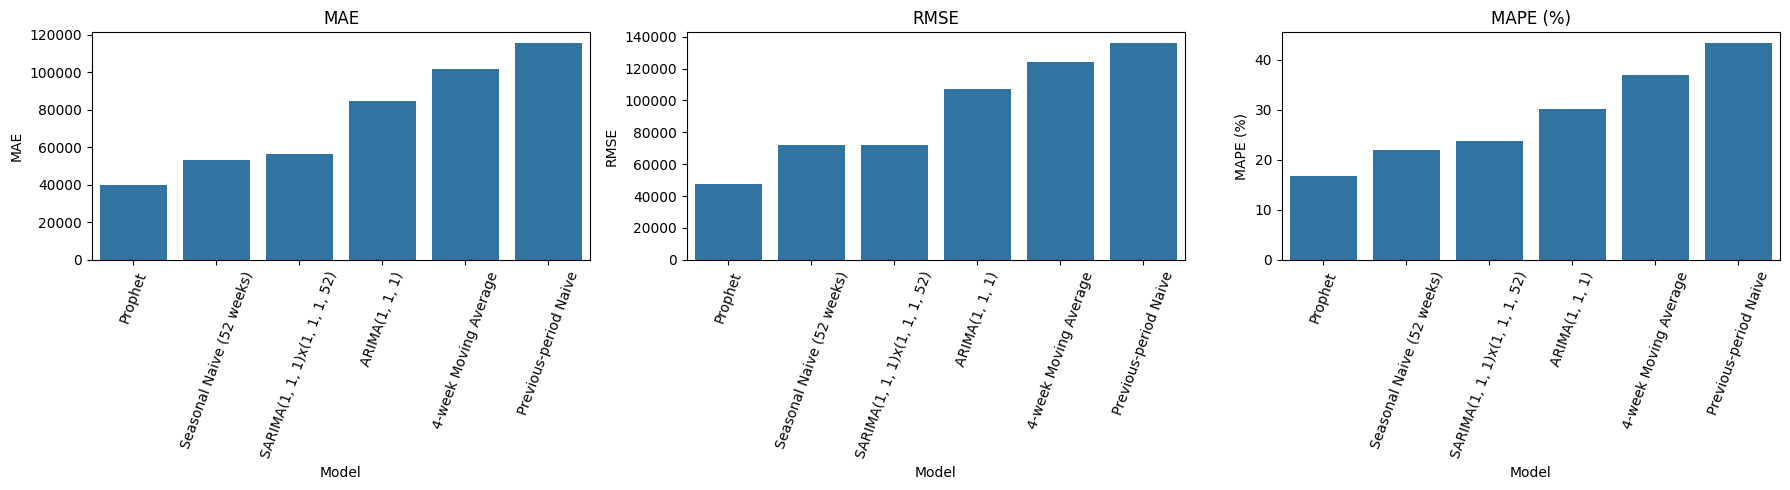

In [36]:
# CELL 32 — Metric plots

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5)
)

for ax, metric in zip(
    axes,
    ["MAE", "RMSE", "MAPE (%)"]
):
    sns.barplot(
        data=results,
        x="Model",
        y=metric,
        ax=ax
    )
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=70)

plt.tight_layout()
plt.show()

## Forecast Comparison

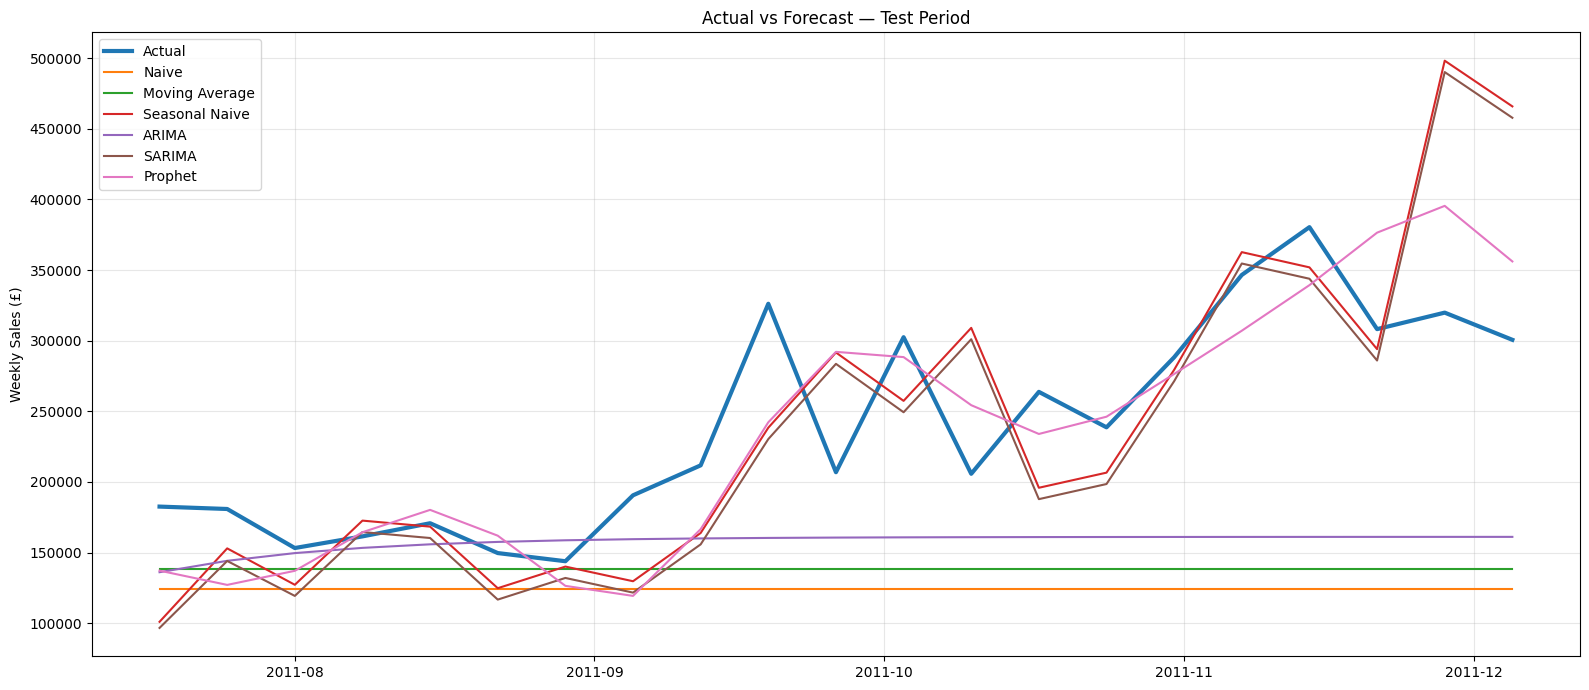

In [37]:
# CELL 33 — Forecast comparison

plt.figure(figsize=(16, 7))

plt.plot(
    test.index,
    test,
    label="Actual",
    linewidth=3
)

plt.plot(test.index, naive_pred, label="Naive")
plt.plot(test.index, moving_average_pred, label="Moving Average")

if "seasonal_naive_pred" in globals():
    plt.plot(
        test.index,
        seasonal_naive_pred,
        label="Seasonal Naive"
    )

plt.plot(test.index, arima_pred, label="ARIMA")

if "sarima_pred" in globals():
    plt.plot(test.index, sarima_pred, label="SARIMA")

if "prophet_pred" in globals():
    plt.plot(test.index, prophet_pred, label="Prophet")

plt.title("Actual vs Forecast — Test Period")
plt.ylabel("Weekly Sales (£)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Select Best Model

In [38]:
# CELL 34 — Pilih model terbaik

best_model = results.iloc[0]["Model"]

print("Best model berdasarkan RMSE:", best_model)

Best model berdasarkan RMSE: Prophet


## Future Forecast

In [39]:
# CELL 35 — Future forecast

FUTURE_PERIODS = 24

future_index = pd.date_range(
    series.index[-1] + pd.Timedelta(weeks=1),
    periods=FUTURE_PERIODS,
    freq="W-MON"
)

if best_model == f"ARIMA{ARIMA_ORDER}":

    final_fit = ARIMA(
        series,
        order=ARIMA_ORDER
    ).fit()

    values = final_fit.forecast(
        steps=FUTURE_PERIODS
    ).values

elif best_model == f"SARIMA{SARIMA_ORDER}x{SARIMA_SEASONAL_ORDER}":

    final_fit = SARIMAX(
        series,
        order=SARIMA_ORDER,
        seasonal_order=SARIMA_SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(
        disp=False,
        maxiter=200
    )

    values = final_fit.forecast(
        steps=FUTURE_PERIODS
    ).values

elif best_model == "Prophet" and PROPHET_AVAILABLE:

    prophet_full = (
        series.rename("y")
        .reset_index()
    )
    prophet_full.columns = ["ds", "y"]

    final_fit = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )

    final_fit.fit(prophet_full)

    future_prophet = final_fit.make_future_dataframe(
        periods=FUTURE_PERIODS,
        freq="W-MON",
        include_history=False
    )

    values = final_fit.predict(
        future_prophet
    )["yhat"].values

elif "Moving Average" in best_model:

    values = np.repeat(
        series.iloc[-WINDOW:].mean(),
        FUTURE_PERIODS
    )

elif "Seasonal Naive" in best_model:

    values = np.resize(
        series.iloc[-52:].values,
        FUTURE_PERIODS
    )

else:

    values = np.repeat(
        series.iloc[-1],
        FUTURE_PERIODS
    )

future_forecast = pd.Series(
    values,
    index=future_index,
    name="forecast"
)

display(future_forecast.to_frame())

,forecast
2011-12-12,240685.405730
2011-12-19,126598.934262
2011-12-26,61227.185341
2012-01-02,77995.267055
2012-01-09,140836.090656
2012-01-16,180833.326257
2012-01-23,165295.330175
2012-01-30,124085.503894
2012-02-06,107971.408354
2012-02-13,130827.820725


## High/Low Demand Period

In [40]:
# CELL 36 — High/low demand periods

high_threshold = future_forecast.quantile(0.75)
low_threshold = future_forecast.quantile(0.25)

future_table = future_forecast.to_frame()

future_table["demand_level"] = np.select(
    [
        future_table["forecast"] >= high_threshold,
        future_table["forecast"] <= low_threshold
    ],
    [
        "High demand",
        "Low demand"
    ],
    default="Normal demand"
)

print("High-demand threshold:", high_threshold)
print("Low-demand threshold :", low_threshold)

display(future_table)

High-demand threshold: 167520.23007821705
Low-demand threshold : 129770.59910931504


,forecast,demand_level
2011-12-12,240685.405730,High demand
2011-12-19,126598.934262,Low demand
2011-12-26,61227.185341,Low demand
2012-01-02,77995.267055,Low demand
2012-01-09,140836.090656,Normal demand
2012-01-16,180833.326257,High demand
2012-01-23,165295.330175,Normal demand
2012-01-30,124085.503894,Low demand
2012-02-06,107971.408354,Low demand
2012-02-13,130827.820725,Normal demand


## Future Forecast Visualization

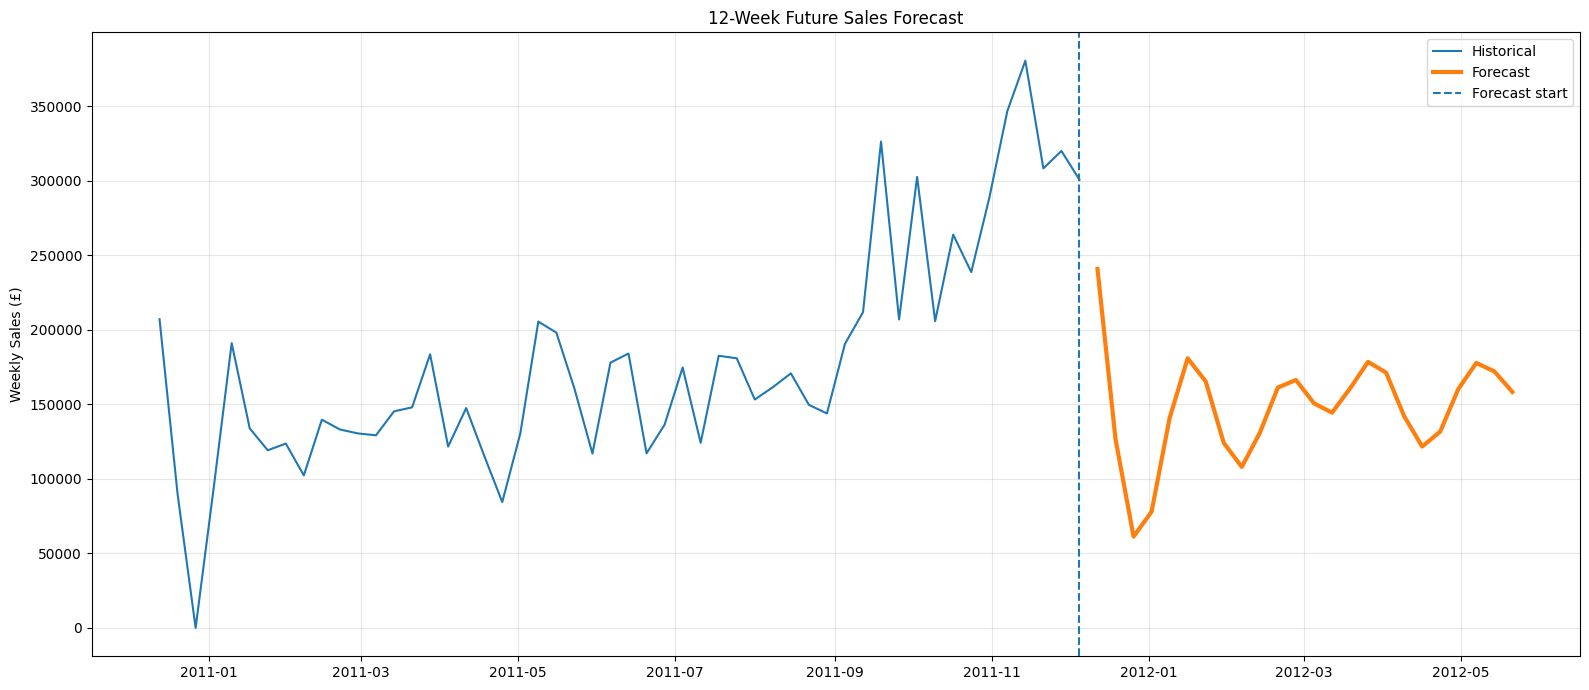

In [41]:
# CELL 37 — Future forecast visualization

plt.figure(figsize=(16, 7))

recent_history = series.iloc[-52:]

plt.plot(
    recent_history.index,
    recent_history,
    label="Historical"
)

plt.plot(
    future_forecast.index,
    future_forecast,
    label="Forecast",
    linewidth=3
)

plt.axvline(
    series.index[-1],
    linestyle="--",
    label="Forecast start"
)

plt.title("12-Week Future Sales Forecast")
plt.ylabel("Weekly Sales (£)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Region Analysis

In [42]:
# CELL 38 — Region analysis

# Dataset tidak mempunyai State.
# Country digunakan sebagai proxy region.

df["RegionProxy"] = np.where(
    df["Country"].eq("United Kingdom"),
    "United Kingdom",
    "Other Countries"
)

region_sales = (
    df.groupby("RegionProxy")["NetRevenue"]
      .sum()
      .sort_values(ascending=False)
)

country_sales = (
    df.groupby("Country")["NetRevenue"]
      .sum()
      .sort_values(ascending=False)
)

display(region_sales)
display(country_sales.head(20))

,NetRevenue
RegionProxy,
United Kingdom,1.638258e+07
Other Countries,2.904667e+06


,NetRevenue
Country,
United Kingdom,1.638258e+07
EIRE,6.155196e+05
Netherlands,5.485249e+05
Germany,4.179886e+05
France,3.281918e+05
Australia,1.671291e+05
Switzerland,9.972876e+04
Spain,9.185948e+04
Sweden,8.780942e+04


## Top Products

In [43]:
# CELL 39 — Top products

top_products = (
    df.groupby(
        ["StockCode", "Description"]
    )["NetRevenue"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

display(top_products)

,,NetRevenue
StockCode,Description,
22423,REGENCY CAKESTAND 3 TIER,327813.65
DOT,DOTCOM POSTAGE,322647.47
85123A,WHITE HANGING HEART T-LIGHT HOLDER,253541.51
47566,PARTY BUNTING,147948.50
85099B,JUMBO BAG RED RETROSPOT,146689.00
84879,ASSORTED COLOUR BIRD ORNAMENT,131413.85
22086,PAPER CHAIN KIT 50'S CHRISTMAS,121662.14
POST,POSTAGE,112341.00
79321,CHILLI LIGHTS,84854.16


## Customer Segmentation Proxy

In [44]:
# CELL 40 — Customer segmentation proxy

# Tidak tersedia Customer Segment resmi.
# Segment dibuat dari historical customer value.

customer_value = (
    df.dropna(subset=["CustomerID"])
      .groupby("CustomerID")["NetRevenue"]
      .sum()
)

customer_segment = pd.qcut(
    customer_value.rank(method="first"),
    q=3,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value"
    ]
)

display(customer_segment.value_counts())

,count
NetRevenue,
Low Value,1981
High Value,1981
Medium Value,1980


## Business Analysis

In [45]:
# CELL 42 — Business analysis

best = results.iloc[0]

print("=" * 70)
print("BUSINESS ANALYSIS")
print("=" * 70)

print(f"Best model : {best['Model']}")
print(f"MAE        : £{best['MAE']:,.2f}")
print(f"RMSE       : £{best['RMSE']:,.2f}")
print(f"MAPE       : {best['MAPE (%)']:.2f}%")

print("\nINVENTORY")
print("1. Tingkatkan safety stock menjelang high-demand periods.")
print("2. Prioritaskan produk dengan demand/revenue historis tinggi.")
print("3. Gunakan low-demand periods untuk stock reduction/replenishment.")

print("\nSTAFFING")
print("4. Tambahkan kapasitas warehouse/order processing pada high-demand periods.")
print("5. Optimalkan staffing pada low-demand periods.")

print("\nPURCHASING")
print("6. Lakukan purchasing lebih awal sebelum demand tinggi.")
print("7. Pertimbangkan supplier lead time dan service level.")
print("8. Forecast bukan stock quantity absolut; safety stock tetap diperlukan.")

BUSINESS ANALYSIS
Best model : Prophet
MAE        : £39,757.38
RMSE       : £47,583.78
MAPE       : 16.75%

INVENTORY
1. Tingkatkan safety stock menjelang high-demand periods.
2. Prioritaskan produk dengan demand/revenue historis tinggi.
3. Gunakan low-demand periods untuk stock reduction/replenishment.

STAFFING
4. Tambahkan kapasitas warehouse/order processing pada high-demand periods.
5. Optimalkan staffing pada low-demand periods.

PURCHASING
6. Lakukan purchasing lebih awal sebelum demand tinggi.
7. Pertimbangkan supplier lead time dan service level.
8. Forecast bukan stock quantity absolut; safety stock tetap diperlukan.


## High/Low Demand Tables

In [46]:
# CELL 43 — High/low demand tables

print("HIGH-DEMAND PERIODS")
display(
    future_table[
        future_table["demand_level"] == "High demand"
    ].sort_values("forecast", ascending=False)
)

print("\nLOW-DEMAND PERIODS")
display(
    future_table[
        future_table["demand_level"] == "Low demand"
    ].sort_values("forecast")
)

HIGH-DEMAND PERIODS


,forecast,demand_level
2011-12-12,240685.405730,High demand
2012-01-16,180833.326257,High demand
2012-03-26,178434.668161,High demand
2012-05-07,177688.118604,High demand
2012-05-14,172037.727314,High demand
2012-04-02,171202.097583,High demand



LOW-DEMAND PERIODS


,forecast,demand_level
2011-12-26,61227.185341,Low demand
2012-01-02,77995.267055,Low demand
2012-02-06,107971.408354,Low demand
2012-04-16,121621.949169,Low demand
2012-01-30,124085.503894,Low demand
2011-12-19,126598.934262,Low demand


## Export hasil

In [47]:
# CELL 44 — Export hasil

OUTPUT_DIR = DATA_PATH.parent / "forecasting_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

OUTPUT_FILE = (
    OUTPUT_DIR /
    "demand_forecasting_results.xlsx"
)

with pd.ExcelWriter(
    OUTPUT_FILE,
    engine="openpyxl"
) as writer:

    daily_forecast.to_excel(
        writer,
        sheet_name="Daily Sales"
    )

    weekly.to_excel(
        writer,
        sheet_name="Weekly Sales"
    )

    monthly.to_excel(
        writer,
        sheet_name="Monthly Sales"
    )

    results.to_excel(
        writer,
        sheet_name="Model Evaluation",
        index=False
    )

    future_table.to_excel(
        writer,
        sheet_name="Future Forecast"
    )

    region_sales.to_excel(
        writer,
        sheet_name="Region Sales"
    )

    country_sales.head(50).to_excel(
        writer,
        sheet_name="Country Sales"
    )

    top_products.to_excel(
        writer,
        sheet_name="Top Products"
    )

print("Saved:", OUTPUT_FILE)

Saved: /content/forecasting_outputs/demand_forecasting_results.xlsx
